In [1]:
import os
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit

import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from pollen_utils import get_clients_population_dict
# srun -w mauao -c 5 --partition=interactive --pty bash
# srun -w ngongotaha -c 5 --partition=interactive --pty bash
# source /nfs-share/ls985/anaconda3/bin/activate ray111-test
# jupyter server --no-browser --port=8889
# ssh -L 8889:localhost:8889 ls985@mauao
# ssh -L 8889:localhost:8889 ls985@ngongotaha

# TODO: change font to times new roman
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'normal'#'bold'

In [42]:
# root_dir, dataset, batch_size = "/nfs-share/ls985/pollen_worker/outputs/2023-10-09/15-42-18", "shakespeare_memory", 10 # Shakespeare lb
# root_dir, dataset, batch_size = "/nfs-share/ls985/pollen_worker/outputs/2023-10-09/15-42-21", "shakespeare_memory", 10 # Shakespeare llb
# root_dir, dataset, batch_size = "/nfs-share/ls985/pollen_worker/outputs/2023-10-09/15-42-27", "openimage", 20 # Openimage lb
root_dir, dataset, batch_size = "/nfs-share/ls985/pollen_worker/outputs/2023-10-09/15-48-41", "openimage", 20 # Openimage llb
# root_dir, dataset, batch_size = "/nfs-share/ls985/pollen_worker/outputs/", "google_speech", 20 # Google Speech
# root_dir, dataset, batch_size = "/nfs-share/ls985/pollen_worker/outputs/", "reddit", 20 # Reddit
CLIENTS_TRAINING_STATS = f"{root_dir}/clients_training_stats.parquet"
# GPU_STATS = f"{root_dir}/gpu_stats.parquet"

In [43]:
ctd = pq.read_table(CLIENTS_TRAINING_STATS).to_pandas()
# gs = pq.read_table(GPU_STATS).to_pandas()

In [44]:
ctd

,node,gpu,cid,start_time,end_time
0,mauao.cl.cam.ac.uk,cuda:0,2271,1696862942592326030,1696862963093864615
1,mauao.cl.cam.ac.uk,cuda:0,13416,1696862943355062695,1696862964016748528
2,mauao.cl.cam.ac.uk,cuda:0,4433,1696862963180773346,1696862964273771562
3,mauao.cl.cam.ac.uk,cuda:0,22981,1696862964300336216,1696862964854974705
4,mauao.cl.cam.ac.uk,cuda:0,5573,1696862964143134276,1696862965401587099
...,...,...,...,...,...
9995,mauao.cl.cam.ac.uk,cuda:0,3089,1696865311860861380,1696865316310366693
9996,mauao.cl.cam.ac.uk,cuda:0,21251,1696865313310397836,1696865316419369356
9997,mauao.cl.cam.ac.uk,cuda:0,1986,1696865314819585515,1696865316619316517
9998,mauao.cl.cam.ac.uk,cuda:0,6024,1696865311860921570,1696865316681128571


In [45]:
# gs

In [46]:
# gs.columns

In [47]:
cid_samples_dict = get_clients_population_dict(
    name=dataset,
    batch_size=1,
    seed=1337
)

DEBUG flwr 2023-10-09 16:36:25,932 | pollen_utils.py:360 | Length of cids list before filtering 11325
DEBUG flwr 2023-10-09 16:36:25,935 | pollen_utils.py:362 | Length of cids list after filtering 11325
DEBUG flwr 2023-10-09 16:36:25,937 | pollen_utils.py:364 | Randomly sampled clients with state 1337


In [48]:
# gs.plot(x=" timestamp", y=" utilization.gpu [%]", figsize=(5, 5))

In [49]:
# gs.plot(x=" timestamp", y=" clocks.current.sm [MHz]", figsize=(5, 5))

In [50]:
ctd['n_samples'] = ctd['cid'].apply(lambda x: cid_samples_dict[x])
ctd['n_batches'] = ctd['n_samples'] // batch_size

In [51]:
ctd['delta_t'] = ctd['end_time'] - ctd['start_time']
ctd['delta_t_s'] = ctd['delta_t'].apply(lambda x: x * 1e-9)

In [52]:

list_of_nodes = list(ctd.node.unique())
list_of_batches = list(ctd.n_batches.unique())
list_of_batches.sort()
ctd['is_outlier'] = False
for node in list_of_nodes:
    quantiles = dict()
    for bs in list_of_batches:
        quantiles[bs] = ctd[(ctd.n_batches == bs) & (ctd.node == node)]['delta_t_s'].quantile(0.66)
    ctd['is_outlier'] = ctd.apply(lambda x: (x['delta_t_s'] > quantiles[x['n_batches']]) if (x['node'] == node) else x['is_outlier'], axis=1)

In [53]:
ctd[ctd["is_outlier"] == True]

,node,gpu,cid,start_time,end_time,n_samples,n_batches,delta_t,delta_t_s,is_outlier
0,mauao.cl.cam.ac.uk,cuda:0,2271,1696862942592326030,1696862963093864615,59,2,20501538585,20.501539,True
1,mauao.cl.cam.ac.uk,cuda:0,13416,1696862943355062695,1696862964016748528,25,1,20661685833,20.661686,True
5,mauao.cl.cam.ac.uk,cuda:0,8498,1696862943802168122,1696862965429789575,49,2,21627621453,21.627621,True
6,mauao.cl.cam.ac.uk,cuda:0,7904,1696862943785454283,1696862965456796984,21,1,21671342701,21.671343,True
7,mauao.cl.cam.ac.uk,cuda:0,12465,1696862943402899171,1696862965723520005,84,4,22320620834,22.320621,True
...,...,...,...,...,...,...,...,...,...,...
9992,mauao.cl.cam.ac.uk,cuda:0,10169,1696865313694805771,1696865316260586993,31,1,2565781222,2.565781,True
9993,mauao.cl.cam.ac.uk,cuda:0,20214,1696865314290861974,1696865316265121884,22,1,1974259910,1.974260,True
9994,mauao.cl.cam.ac.uk,cuda:0,2978,1696865311861094294,1696865316278732196,179,8,4417637902,4.417638,True
9996,mauao.cl.cam.ac.uk,cuda:0,21251,1696865313310397836,1696865316419369356,49,2,3108971520,3.108972,True


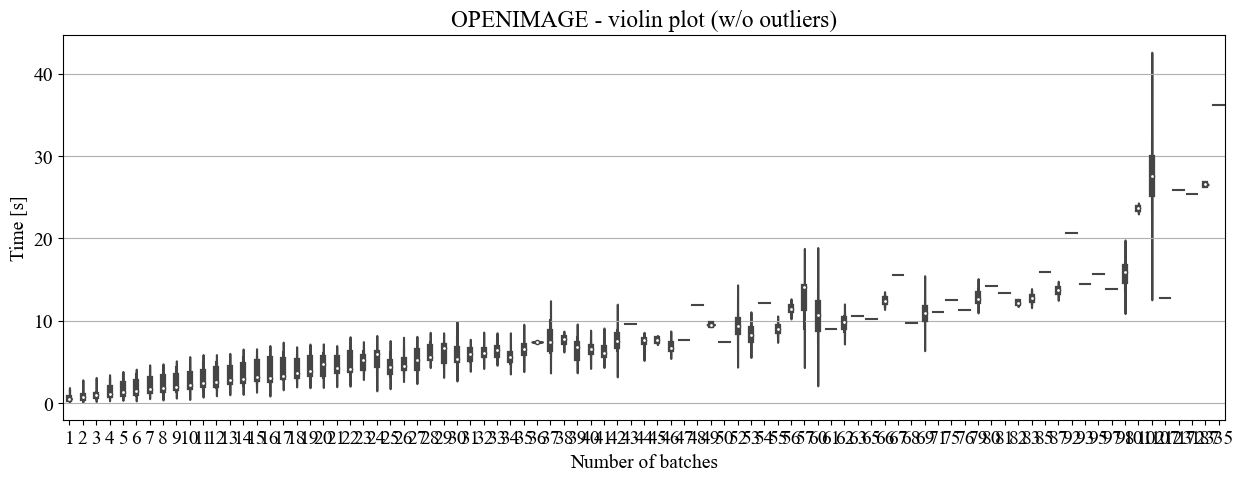

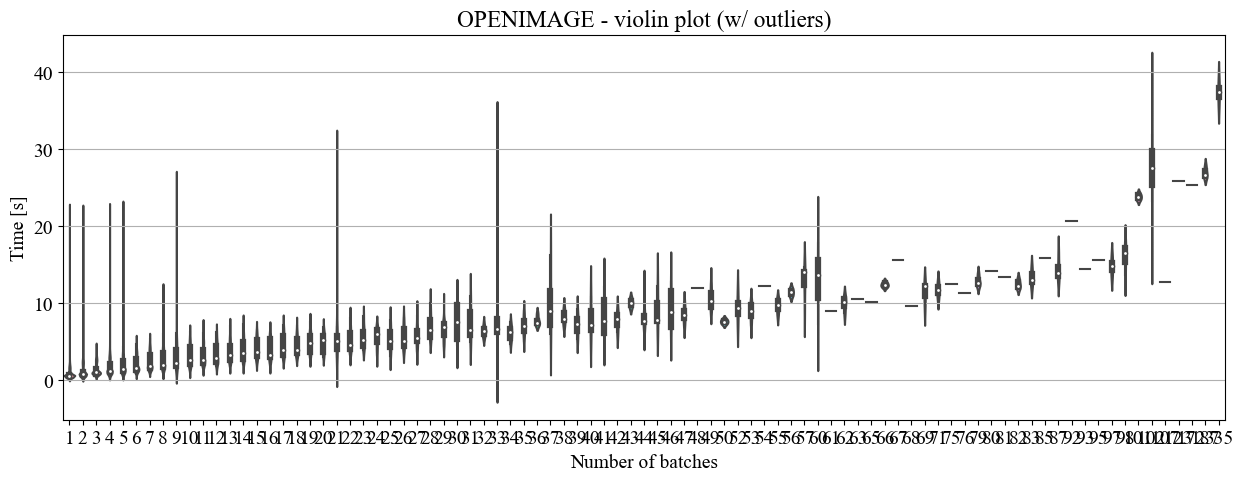

In [54]:
plt.figure(figsize=(15, 5))
sns.violinplot(
    data=ctd[ctd["is_outlier"] == False],
    x="n_batches",
    y="delta_t_s",
)
plt.ylabel("Time [s]")
plt.xlabel("Number of batches")
plt.title(f"{dataset.upper()} - violin plot (w/o outliers)")
plt.grid(axis='y')
# plt.savefig(f"{dataset}_violinplot_wo_outliers.pdf", format="pdf", dpi=800, bbox_inches='tight')
plt.show()

plt.figure(figsize=(15, 5))
sns.violinplot(
    data=ctd,
    x="n_batches",
    y="delta_t_s",
)
plt.ylabel("Time [s]")
plt.xlabel("Number of batches")
plt.title(f"{dataset.upper()} - violin plot (w/ outliers)")
plt.grid(axis='y')
# plt.savefig(f"{dataset}_violinplot_w_outliers.pdf", format="pdf", dpi=800, bbox_inches='tight')
plt.show()

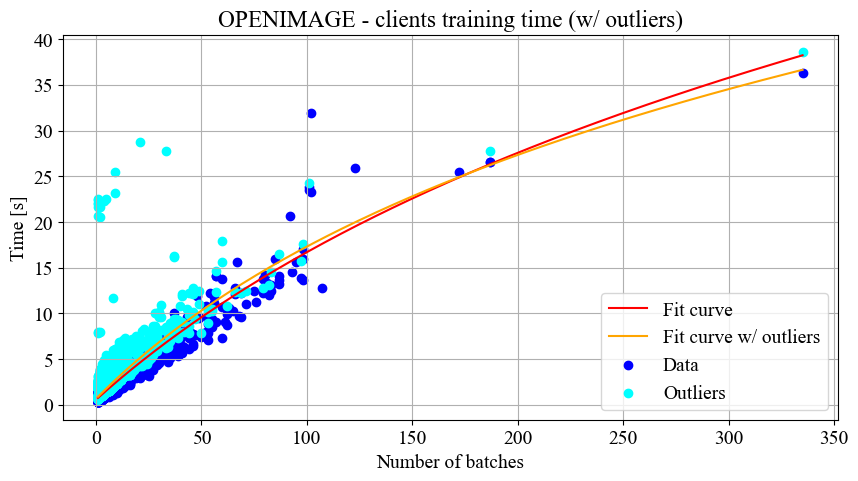

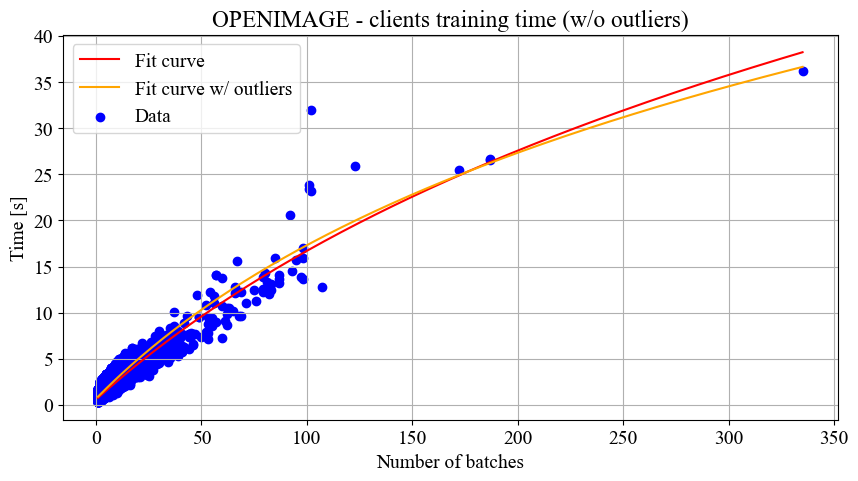

In [55]:
df = ctd[ctd["is_outlier"] == True]
x_data_out = df["n_batches"].values
y_data_out = df["delta_t"].values * 1e-9
df = ctd[ctd["is_outlier"] == False]
x_data = df["n_batches"].values
y_data = df["delta_t"].values * 1e-9
model = lambda x, A, B, offset:  offset+A*np.log(x+B)
popt, pcov = curve_fit(
    model,
    x_data,
    y_data,
    p0=[0,0,0]
)
df = ctd
x_data_all = df["n_batches"].values
y_data_all = df["delta_t"].values * 1e-9
popt_all, pcov_all = curve_fit(
    model,
    x_data_all,
    y_data_all,
    p0=[0,0,0]
)

plt.figure(figsize=(10, 5))
x = np.linspace(x_data.min(),x_data.max(),250)
plt.plot(x, model(x,*popt), label="Fit curve", color="red")
plt.plot(x, model(x,*popt_all), label="Fit curve w/ outliers", color="orange")
plt.scatter(x_data, y_data, label="Data", color="blue")
plt.scatter(x_data_out, y_data_out, label="Outliers", color="cyan")
plt.ylabel("Time [s]")
plt.xlabel("Number of batches")
plt.legend()
plt.title(f"{dataset.upper()} - clients training time (w/ outliers)")
plt.grid()
# plt.savefig(f"{dataset}_ctt_data_fit_w_outliers.pdf", format="pdf", dpi=800, bbox_inches='tight')

plt.figure(figsize=(10, 5))
x = np.linspace(x_data.min(),x_data.max(),250)
plt.plot(x, model(x,*popt), label="Fit curve", color="red")
plt.plot(x, model(x,*popt_all), label="Fit curve w/ outliers", color="orange")
plt.scatter(x_data, y_data, label="Data", color="blue")
plt.ylabel("Time [s]")
plt.xlabel("Number of batches")
plt.legend()
plt.title(f"{dataset.upper()} - clients training time (w/o outliers)")
plt.grid()
# plt.savefig(f"{dataset}_ctt_data_fit_wo_outliers.pdf", format="pdf", dpi=800, bbox_inches='tight')